# This Notebook is used to create a visual representation of the camera trajectories

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image

In [ ]:
poses=[]
vertex_ids = []
vertex_times = []
times = []
for i in range(0,100,1):
    filename = filename=f"/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/loc_result/T_r_vertex_{i:04d}.txt"
    matrix = []
    
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.startswith('vertex_id:'):
                vertex_id =int(line.split(": ")[1].strip())
                vertex_ids.append(vertex_id)
            elif line.startswith('vertex_timestamp:'):
                vertex_time =int(line.split(": ")[1].strip())
                vertex_times.append(vertex_time)
            elif line.startswith("timestamp:"):
                time =int(line.split(": ")[1].strip())
                times.append(time)
            elif line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)
            

    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
poses=np.array(poses)
times= np.array(times)
vertex_ids = np.array(vertex_ids)
vertex_times= np.array(vertex_times)

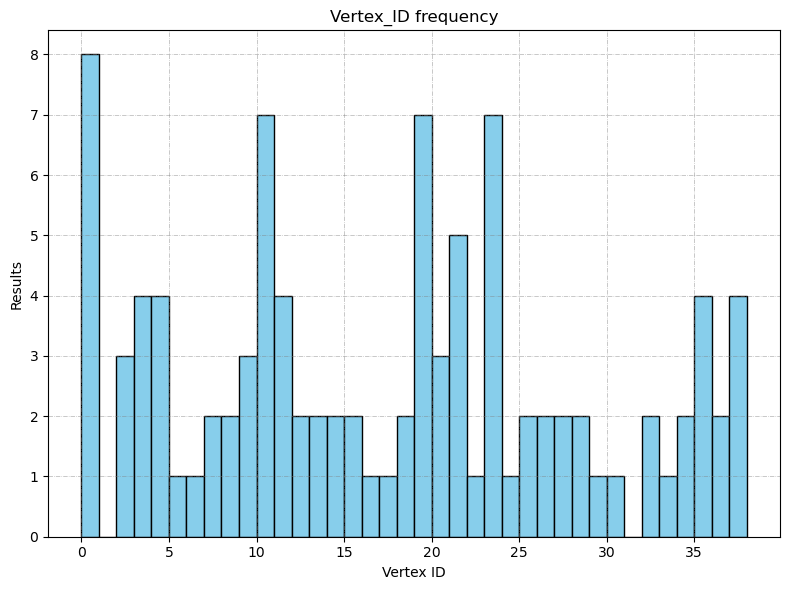

In [29]:
fig, axs = plt.subplots(1, 1, figsize =(8, 6), tight_layout = True)
axs.grid( color ='grey', linestyle ='-.', linewidth = 0.5, alpha = 0.6) 
plt.hist(vertex_ids, bins=max(vertex_ids), color='skyblue', edgecolor='black')
plt.xlabel('Vertex ID')
plt.ylabel('Results')
plt.title('Vertex_ID frequency')
plt.show()

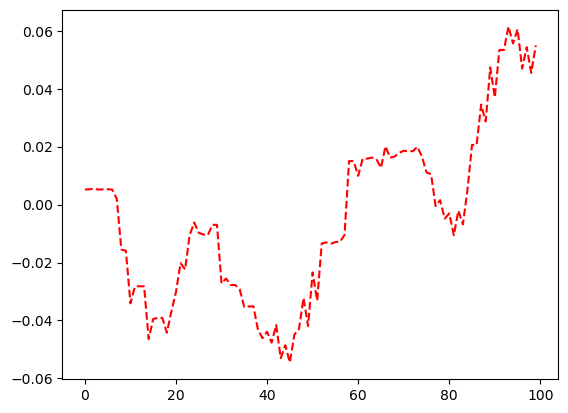

In [ ]:
# Graph of the y distance to vertex.
origins = poses[:, :3, -1]
plt.plot(origins[:,1], 'r--')
plt.show()

[[-3.44111e-02  5.19264e-03 -1.05542e-04]
 [-3.45640e-02  5.28934e-03 -4.52213e-05]
 [-3.48536e-02  5.46417e-03  9.48494e-05]
 [-3.44099e-02  5.18596e-03 -1.23795e-04]
 [-3.45194e-02  5.26482e-03 -8.51927e-05]
 [-3.45744e-02  5.29689e-03 -5.99106e-05]
 [-3.44128e-02  5.18796e-03 -1.22547e-04]]


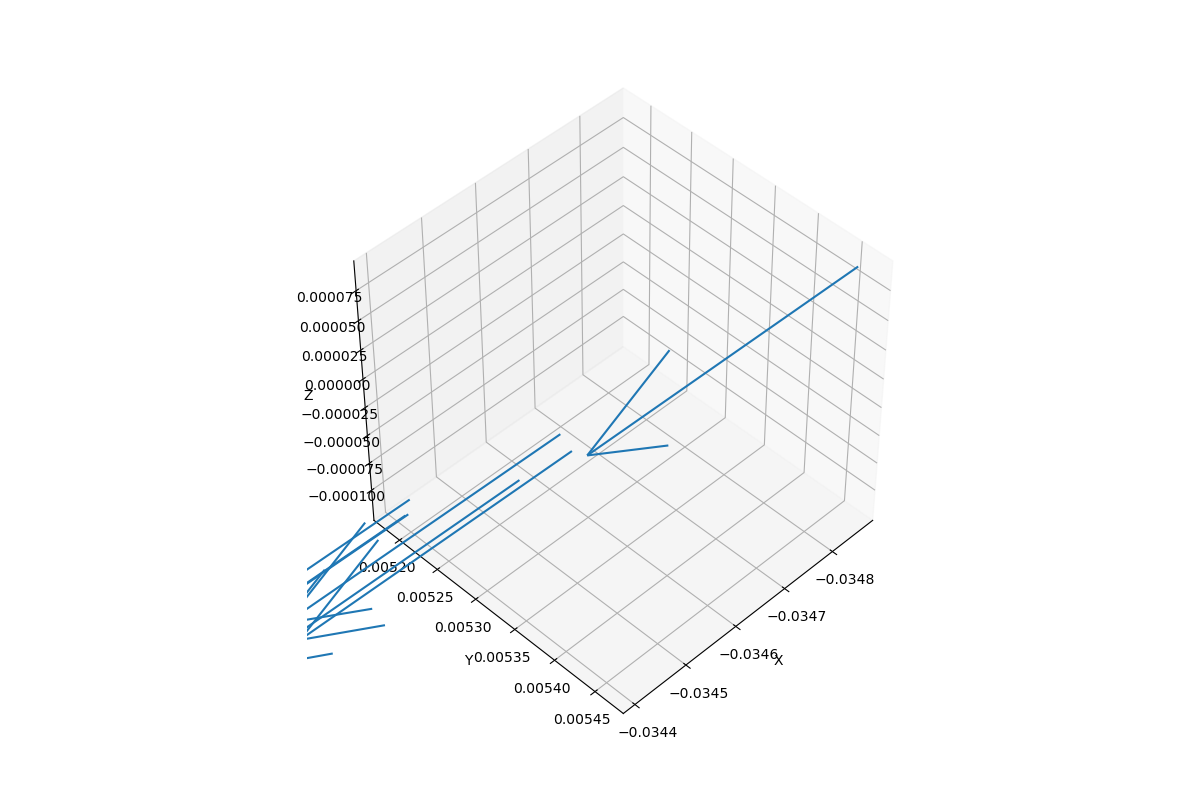

In [44]:
%matplotlib ipympl
poses1=poses[0:7]
origins = poses1[:, :3, -1]
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in poses1])
print(origins)

ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  dirs[..., 0].flatten(),
  dirs[..., 1].flatten(),
  dirs[..., 2].flatten(), length=0.0005, normalize=True)
ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(45, 45) 
plt.show()